### Download days with potential storm detections
- Ignore storms above 60N and below 60S

In [1]:
import os
import pandas as pd
import requests

# Create main folder to save detections
saveFolder = "marci_seen"
os.makedirs(saveFolder, exist_ok=True)

# Create subfolders /band1 to /band5
bandToUse = [1, 2, 4, 5]
for band in bandToUse:
    subfolderName = "band" + str(band)
    fullPath = os.path.join(saveFolder, subfolderName)
    os.makedirs(fullPath, exist_ok=True)

df = pd.read_csv("MDAD_trimmed.csv")   # automatically handles headers
arr = df.to_numpy()            # convert to NumPy array
print(df.columns.tolist())

for row in df.iloc.itertuples(index=True, name="Row"):

  mission_subphase = row[2]
  mission_day = row[3]
  center_longitude = row[5]
  storm_area = row[7]
  max_latitude = row[10]
  min_latitude = row[11]

  # Ignore storm occurences above 60N and below 60S
  if max_latitude > 60 or min_latitude < -60:
    pass

  # Download image from each band
  for band in bandToUse:
    baseUrl = "https://dwjtvz5c9xobz.cloudfront.net/mars_mro_marci_dailyglobalmosaics_wang_2023/data/"
    filename = row[2] + "_day" + str(row[3]).zfill(2) + "_band000"+ str(bandToUse) + "_resx2.tiff"
    fileUrl = baseUrl + "data_" + row[2] + "/data_resx2/band000" + str(bandToUse) + "/" + filename
    subfolderName = "band" + str(band)
    localPath = os.path.join(saveFolder, subfolderName, filename)

    if os.path.isfile(localPath):
      pass

    print(f"Trying to download {filename}...")

    try:
      response = requests.get(fileUrl, timeout=20)
      response.raise_for_status()

      # Save the file
      with open(localPath, "wb") as f:
        f.write(response.content)
        print(f"Downloaded {filename} successfully.")
      
    except requests.RequestException:
      print(f"Could not download {filename}. Skipping.")
      continue


['Mission Subphase', 'Sol', 'Centroid Longitude', 'Centroid Latitude', 'Area', 'Maximum Latitude', 'Minimum Latitude', 'Confidence Interval', 'Horizontal Distance', 'Vertical Distance']


AttributeError: '_iLocIndexer' object has no attribute 'itertuples'

### Crop potential storm detections
- Write detections and calculated dimensions into a CSV file

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import csv

MARS_RADIUS = 3389.5

# The storm area is not a perfect square
# We may have to multiply the longitude difference (delta) for better visuals
LONGITUDE_MULTIPLIER = 3

# Take additional latitude delta to capture storm better
lat_delta = 3

# Create main folder to save crops
picFolder = "marci_potential_storm_detections"
saveFolder = "marci_potential_storm_cropped"
os.makedirs(saveFolder, exist_ok=True)

# Create subfolders /band1 to /band5
bandToUse = [1, 2, 3, 4, 5]
for band in bandToUse:
    subfolderName = "band" + str(band)
    fullPath = os.path.join(saveFolder, subfolderName)
    os.makedirs(fullPath, exist_ok=True)

# Create subset of MDAD with potential storm croppings
with open("MDAD_trimmed.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Mission Subphase", "Sol", "Centroid Longitude", "Centroid Latitude", 
                     "Area", "Maximum Latitude", "Minimum Latitude", "Confidence Interval",
                     "Horizontal Distance", "Vertical Distance"])
    
for row in df.iloc[:2025].itertuples(index=True, name="Row"):
  mission_subphase = row[2]
  mission_day = row[3]
  center_longitude = row[5]
  center_latitude = row[6]
  storm_area = row[7]
  max_latitude = row[10]
  min_latitude = row[11]
  confidence_interval = row[12]

  # Ignore storm occurences above 60N and below 60S
  if max_latitude > 60 or min_latitude < -60:
    continue

  # Estimate min and max longitude given bounding box
  # We assume Mars is a sphere with MARS_RADIUS = 3389.5 km
  min_latitude_rads = np.radians(min_latitude)
  max_latitude_rads = np.radians(max_latitude)
  center_longitude_rads = np.radians(center_longitude)

  # Compute Δλ in radians
  delta_lambda = storm_area / (MARS_RADIUS**2 * (np.sin(max_latitude_rads) - np.sin(min_latitude_rads)))
  adjusted_lambda = LONGITUDE_MULTIPLIER * delta_lambda

  # Compute longitude bounds in radians
  # - Actual bounds used for distance calculation
  # - Adjusted bounds used for cropping storm images 
  min_longitude_rads_actual = center_longitude_rads - delta_lambda / 2
  max_longitude_rads_actual = center_longitude_rads + delta_lambda / 2
  min_longitude_rads_adjusted = center_longitude_rads - adjusted_lambda / 2
  max_longitude_rads_adjusted = center_longitude_rads + adjusted_lambda / 2

  # Convert back to degrees and wrap to [-180, 180]
  min_longitude_adjusted = (np.degrees(min_longitude_rads_adjusted) + 180) % 360 - 180
  max_longitude_adjusted = (np.degrees(max_longitude_rads_adjusted) + 180) % 360 - 180

  # Get approximate horizontal and vertical distance of storm
  horizontal_distance = abs(MARS_RADIUS * math.cos(np.rads(center_latitude)) * delta_lambda)
  vertical_distance = abs(MARS_RADIUS * (max_latitude_rads - min_latitude_rads))

  # Write updated values into MDAD_trimmed.csv
  writer.writerow([mission_subphase, mission_day, center_longitude, center_latitude,
                   storm_area, max_latitude, min_latitude, confidence_interval,
                   horizontal_distance, vertical_distance])

  for band in bandToUse:
      filename = row[2] + "_day" + str(row[3]).zfill(2) + "_band000"+ str(bandToUse) + "_resx2.tiff"
      subfolderName = "band" + str(band)
      localPath = os.path.join(picFolder, subfolderName, filename)
      img = Image.open(localPath)
      img = np.array(img)

      img_height, img_width = img.shape[:2]
      top_border = img_height - int((max_latitude + 90 + lat_delta) / 180 * img_height)
      bottom_border = img_height - int((min_latitude + 90 - lat_delta) / 180 * img_height)

      left_border = int((min_longitude_adjusted + 180) / 360 * img_width)
      right_border = int((max_longitude_adjusted + 180) / 360 * img_width)

      slice_cols = img[top_border:bottom_border+1, left_border:right_border+1]

      output_filepath = os.path.join(saveFolder, subfolderName, filename)
      cropped_image = Image.fromarray(slice_cols)
      cropped_image.save(output_filepath)

### Download unseen images for testing (J/K Mission Subphases)

In [ ]:
import os
import pandas as pd
import requests

# Create main folder to save unseen detections
saveFolder = "marci_unseen"
os.makedirs(saveFolder, exist_ok=True)

# Create subfolders /band1 to /band5
bandToUse = [3]
for band in bandToUse:
    subfolderName = "band" + str(band)
    fullPath = os.path.join(saveFolder, subfolderName)
    os.makedirs(fullPath, exist_ok=True)

J_mission_subphases = [f"J{str(i).zfill(2)}" for i in range(1, 15)]
K_mission_subphases = [f"K{str(i).zfill(2)}" for i in range(1, 15)]
unseen_mission_subphases = J_mission_subphases + K_mission_subphases

for mission_subphase in unseen_mission_subphases:
    for day in range(1, 33+1):
        for band in bandToUse:
            
            baseUrl = "https://dwjtvz5c9xobz.cloudfront.net/mars_mro_marci_dailyglobalmosaics_wang_2023/data/"
            filename = mission_subphase + "_day" + str(day).zfill(2) + "_band000"+ str(band) + "_resx2.tiff"
            fileUrl = baseUrl + "data_" + mission_subphase + "/data_resx2/band000" + str(band) + "/" + filename
            subfolderName = "band" + str(band)
            localPath = os.path.join(saveFolder, subfolderName, filename)

            if os.path.isfile(localPath):
              pass

            print(f"Trying to download {filename}...")

            try:
              response = requests.get(fileUrl, timeout=20)
              response.raise_for_status()

              # Save the file
              with open(localPath, "wb") as f:
                f.write(response.content)
                print(f"Downloaded {filename} successfully.")
      
            except requests.RequestException:
              print(f"Could not download {filename}. Skipping.")
              continue


### Download and tile negative detections 

In [ ]:
from PIL import Image
import io
import math
import os
import pandas as pd
import requests

MEDIAN_HORIZONTAL_STORM_DISTANCE = 443
MEDIAN_VERTICAL_STORM_DISTANCE = 632

# Create main folder to save detections
saveFolder = "marci_band3/negative_detections"
os.makedirs(saveFolder, exist_ok=True)

# Collect only negative detections from Band 3
bandToUse = [3]

df = pd.read_csv("MDAD_trimmed.csv")   # automatically handles headers
arr = df.to_numpy()                    # convert to NumPy array
print(df.columns.tolist())

mission_subphase_extents = [
    ("D", 2, 22),
    ("F", 1, 4),
    ("G", 1, 23),
    ("P", 1, 22),
]

mission_subphase_list = [
    f"{prefix}{i:02d}" 
    for prefix, start, end in mission_subphase_extents 
    for i in range(start, end + 1)
]

existing_storm_days = set(zip(df['Mission Subphase'], df['Sol']))

for mission_subphase in mission_subphase_list:
    for mission_day in range(1, 33+1):
        if (mission_subphase, mission_day) not in existing_storm_days:

            # Download image from each band
            for band in bandToUse:
                baseUrl = "https://dwjtvz5c9xobz.cloudfront.net/mars_mro_marci_dailyglobalmosaics_wang_2023/data/"
                filename = mission_subphase + "_day" + str(mission_day).zfill(2) + "_band000"+ str(band) + "_resx2.tiff"
                fileUrl = baseUrl + "data_" + mission_subphase + "/data_resx2/band000" + str(band) + "/" + filename

            print(f"Trying to download {filename}...")

            try:
                response = requests.get(fileUrl, timeout=20)
                response.raise_for_status()

                # Load TIFF image from response.content
                img = Image.open(io.BytesIO(response.content))

                width, height = img.size

                # Latitude bounds
                lat_top = 60     # 60N
                lat_bottom = -60 # 60S

                # Convert latitude to pixel rows
                # 90N -> row 0, 90S -> row height
                top_row = int((90 - lat_top) / 180 * height)
                bottom_row = int((90 - lat_bottom) / 180 * height)

                # Crop image to give only 60N to 60S
                cropped_img = img.crop((0, top_row, width, bottom_row))

                cropped_img_width, cropped_img_height = cropped_img.size

                # Mars constants
                MARS_RADIUS_KM = 3389.5
                KM_PER_DEG = 2 * math.pi * MARS_RADIUS_KM / 360

                # Convert km -> degrees
                tile_width_deg = MEDIAN_HORIZONTAL_STORM_DISTANCE / KM_PER_DEG
                tile_height_deg = MEDIAN_VERTICAL_STORM_DISTANCE / KM_PER_DEG

                # Degrees per pixel
                deg_per_px_x = 360 / cropped_img_width
                deg_per_px_y = 120 / cropped_img_height # 60N to 60S

                # Tile size in pixels
                tile_px_w = int(tile_width_deg / deg_per_px_x)
                tile_px_h = int(tile_height_deg / deg_per_px_y)

                # Overlap (set to 0 for no overlap)
                overlap_x = int(tile_px_w * 0.1)  # 20% overlap
                overlap_y = int(tile_px_h * 0.1)

                step_x = tile_px_w - overlap_x
                step_y = tile_px_h - overlap_y

                tiles = []
                tile_id = 0

                for y in range(0, cropped_img_height - tile_px_h + 1, step_y):
                    for x in range(0, cropped_img_width - tile_px_w + 1, step_x):
                        tile = img.crop((x, y, x + tile_px_w, y + tile_px_h))
                        tiles.append(tile)

                        # Optional save
                        save_path = os.path.join(saveFolder, f"mars_tile_{mission_subphase}_{mission_day}_{tile_id:04d}.tiff")
                        tile.save(save_path)
                        tile_id += 1

                print(f"Generated {tile_id} tiles from {mission_subphase} - day {mission_day}")
      
            except requests.RequestException:
                print(f"Could not download {filename}. Skipping.")
                continue



### Download clean mosaics for RetinaNet

In [1]:
from PIL import Image
import io
import math
import os
import pandas as pd
import requests

# Create main folder to save detections
saveFolder = "marci_unseen/band3"
os.makedirs(saveFolder, exist_ok=True)

# Collect all mosaics from Band 3
bandToUse = [3]

mission_subphase_extents = [
    #("B", 1, 22),
    #("D", 1, 22),
    #("F", 1, 4),
    #("G", 1, 23),
    #("P", 1, 22),
    ("K", 1, 13)
]

mission_subphase_list = [
    f"{prefix}{i:02d}" 
    for prefix, start, end in mission_subphase_extents 
    for i in range(start, end + 1)
]

for mission_subphase in mission_subphase_list:
    for mission_day in range(1, 33+1):
        
        # Download image from each band
        for band in bandToUse:
            baseUrl = "https://dwjtvz5c9xobz.cloudfront.net/mars_mro_marci_dailyglobalmosaics_wang_2023/data/"
            filename = mission_subphase + "_day" + str(mission_day).zfill(2) + "_band000"+ str(band) + "_resx2.tiff"
            fileUrl = baseUrl + "data_" + mission_subphase + "/data_resx2/band000" + str(band) + "/" + filename
            localPath = os.path.join(saveFolder, filename)

            if os.path.isfile(localPath):
              continue

            print(f"Trying to download {filename}...")

            try:
              response = requests.get(fileUrl, timeout=20)
              response.raise_for_status()

              # Save the file
              with open(localPath, "wb") as f:
                f.write(response.content)
                print(f"Downloaded {filename} successfully.")
      
            except requests.RequestException:
              print(f"Could not download {filename}. Skipping.")
              continue


Trying to download K12_day01_band0003_resx2.tiff...
Could not download K12_day01_band0003_resx2.tiff. Skipping.
Trying to download K12_day02_band0003_resx2.tiff...
Could not download K12_day02_band0003_resx2.tiff. Skipping.
Trying to download K12_day03_band0003_resx2.tiff...
Could not download K12_day03_band0003_resx2.tiff. Skipping.
Trying to download K12_day04_band0003_resx2.tiff...
Could not download K12_day04_band0003_resx2.tiff. Skipping.
Trying to download K12_day05_band0003_resx2.tiff...
Could not download K12_day05_band0003_resx2.tiff. Skipping.
Trying to download K12_day06_band0003_resx2.tiff...
Could not download K12_day06_band0003_resx2.tiff. Skipping.
Trying to download K12_day07_band0003_resx2.tiff...
Could not download K12_day07_band0003_resx2.tiff. Skipping.
Trying to download K12_day08_band0003_resx2.tiff...
Could not download K12_day08_band0003_resx2.tiff. Skipping.
Trying to download K12_day09_band0003_resx2.tiff...
Could not download K12_day09_band0003_resx2.tiff. Sk

KeyboardInterrupt: 

### Convert Trimmed CSV to RetinaNet CSV
- RetinaNet-compatible CSV contains bounding box pixel dimensions and associated mosaic

In [12]:
import pandas as pd

# --- CONFIGURATION ---
INPUT_CSV = 'MDAD_trimmed.csv'
OUTPUT_CSV = 'MDAD_trimmed_retinanet.csv'

IMG_W = 7200
IMG_H = 3600
MARS_EQ_CIRCUMFERENCE_KM = 21344.0  # At the equator

# Conversion Factors
KM_PER_DEG_LAT = MARS_EQ_CIRCUMFERENCE_KM / 360.0 # ~59.29 km/deg

# Constants based on your map bounds
PX_PER_DEG = 20.0 # (7200 pixels / 360 degrees)

def convert_to_pixels(row):
    # Ensure values are floats to prevent integer division errors
    lon_c = float(row['Centroid Longitude'])
    lat_c = float(row['Centroid Latitude'])
    h_km = float(row['Horizontal Distance'])
    v_km = float(row['Vertical Distance'])
    
    h_deg = h_km / KM_PER_DEG_LAT
    v_deg = v_km / KM_PER_DEG_LAT
    
    # 1. Calculate boundaries in degrees
    # Longitude: -180 to 180
    l_deg = lon_c - (h_deg / 2)
    r_deg = lon_c + (h_deg / 2)
    
    # Latitude: 90 (North) to -90 (South)
    t_deg = lat_c + (v_deg / 2) # Top edge
    b_deg = lat_c - (v_deg / 2) # Bottom edge
    
    # 2. Convert to Pixel Space
    # X: Shift -180 to 0 by adding 180, then multiply by 20
    xmin = (l_deg + 180) * PX_PER_DEG
    xmax = (r_deg + 180) * PX_PER_DEG
    
    # Y: 90 is pixel 0, -90 is pixel 3600
    # The formula is: (90 - Latitude) * 20
    ymin = (90 - t_deg) * PX_PER_DEG
    ymax = (90 - b_deg) * PX_PER_DEG
    
    # 3. Validation & Clamping 
    # This prevents the "zeroing out" if a storm is slightly off-map
    xmin = max(0, min(IMG_W, xmin))
    xmax = max(0, min(IMG_W, xmax))
    ymin = max(0, min(IMG_H, ymin))
    ymax = max(0, min(IMG_H, ymax))

    # Safety check: if xmin == xmax, we have a 1-pixel line, not a box.
    # We ensure at least a 2-pixel width/height so RetinaNet doesn't crash.
    if xmax - xmin < 1: xmax += 2
    if ymax - ymin < 1: ymax += 2

    return [xmin, ymin, xmax, ymax]

# Load your source
df = pd.read_csv(INPUT_CSV)

# Generate list for new CSV
processed_data = []

for _, row in df.iterrows():
    coords = convert_to_pixels(row)
    
    # Construct filename: J01_day01.tiff
    fname = f"{row['Mission Subphase']}_day{str(int(row['Sol'])).zfill(2)}_band0003_resx2.tiff"
    
    processed_data.append({
        'filename': fname,
        'xmin': coords[0],
        'ymin': coords[1],
        'xmax': coords[2],
        'ymax': coords[3]
    })

# Save to CSV
final_df = pd.DataFrame(processed_data)
final_df.to_csv(OUTPUT_CSV, index=False)

# Debug print to check the first few rows
print(final_df.head())

                        filename         xmin         ymin         xmax  \
0  B01_day02_band0003_resx2.tiff  1236.792541  1908.099193  1281.207459   
1  B01_day12_band0003_resx2.tiff  1473.714208  2017.194369  1596.285792   
2  B01_day14_band0003_resx2.tiff  4022.660256  2524.156821  4187.339744   
3  B01_day18_band0003_resx2.tiff  3953.992047  2530.147986  4088.007953   
4  B01_day19_band0003_resx2.tiff  4155.767929  2526.064054  4226.232071   

          ymax  
0  1997.900407  
1  2192.805631  
2  2665.843179  
3  2663.852014  
4  2583.935946  


### Visualise Bounding Boxes on Mosaic

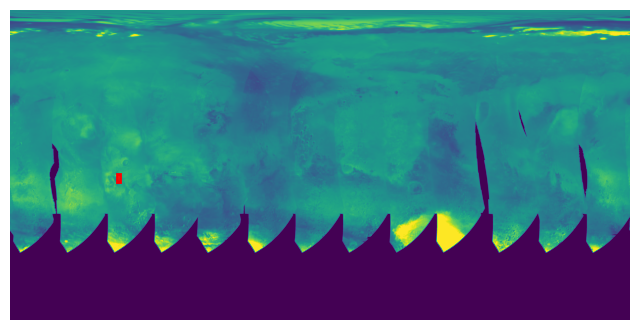

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# ---- CONFIG ----
image_path = "marci_seen/B01_day02_band0003_resx2.tiff"

# List of bounding boxes: (xmin, ymin, xmax, ymax)
bboxes = [
    (1236.7925406414242, 1908.0991934154406, 1281.207459358576, 1997.9004065845593)
]

# Load image
img = Image.open(image_path)

fig, ax = plt.subplots(1, figsize=(8, 6))
ax.imshow(img)

# Draw boxes
for i, (xmin, ymin, xmax, ymax) in enumerate(bboxes):
    width = xmax - xmin
    height = ymax - ymin

    rect = patches.Rectangle(
        (xmin, ymin),
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

   

ax.axis("off")
plt.show()
